<a href="https://colab.research.google.com/github/denisejroth/bags-vectors-transformers/blob/main/SentenceTransformers/notebooks/1_sent_transf_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bags, Vectors & Transformers
## Text embeddings with Sentence Transformers

**A Methods Workshop in Computational Text Analysis**
- Art Dewulf · Public Administration and Policy Group · Wageningen University and Research
- Denise J. Roth · Strategic Communication Group · Wageningen University & Research

---

Sentence Transformers leverage contextual embeddings from BERT or GPT models to convert sentences or larger chunks of text into embedding vectors. Sentence Transformers are trained such that text chunks that are similar in semantic meaning are converted to embedding vectors that are close to each other in the vector space (often captured through cosine similarity). Sentence transformer models can be used for a variety of NLP tasks, including retrieval, deduplication, keyword extraction, classification and topic modeling.

We illustrate some of these applications in this notebook:
- text retrieval
- deduplication
- keyword extraction
- sentiment analysis
- text classification

> **Important — turn on the GPU!** In Colab: *Runtime → Change runtime type → T4 GPU*.
> Sentence Transformers are slow on CPU, although smaller models can also run on CPU.


# Preliminaries


In [12]:
# sentence_transformers library for converting text into embedding vectors
from sentence_transformers import SentenceTransformer

# cosine_similarity metric from sklearn library to compare embedding vectors
from sklearn.metrics.pairwise import cosine_similarity

# datasets
import datasets

# pandas library for DataFrames
import pandas as pd

# numpy library for arrays (matrices)
import numpy as np

# matplotlib library for plotting
from matplotlib import pyplot as plt

# Check whether a GPU is available — this makes Sentence Transformers much faster
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Running on:", device.upper())
if device == "cpu":
    print("⚠️  No GPU detected. Things will be slow. "
          "Consider: Runtime → Change runtime type → T4 GPU.")

Running on: CUDA


# Load Sentence Transformer model

- for most of the Sentence Transformer models, you need to create an account on https://huggingface.co
- we use the model `embeddinggemma-300m`, for which you need to accept the license, so go to https://huggingface.co/google/embeddinggemma-300m and click on the license
- in your Huggingface account settings, go to Access Tokens, and create a token with the name HF_TOKEN, and when you see the token (a long list of letters) copy it because it will only be shown once
- in this Google Colab go to the Secrets tab, and Add new secret, with the name HF_TOKEN and the value (the long list of letters) from Huggingface
- finally, check the switch that says Notebook access, to give this Colab notebook access to the token

This Sentence Transformer model generates 768-dimensional embedding vectors, which means that each text chunk will be transformed in to a list of 768 numbers, which are like coordinates in a 768-dimensional space. Each text chunk becomes a point in this multidimensional space, and the model is trained such that text chunks with highly similar semantic meaning end up close to each other in this space, while chunks with very different different semantic meaning end up far away from each other in the space.

In [13]:
# load Sentence Transformer model embeddinggemma-300m, a 300 million parameter model
# that can be applied to texts of maximum 2048 tokens, generating embedding vectors
# with 768 dimensions
model = SentenceTransformer('google/embeddinggemma-300m')
model

modules.json:   0%|          | 0.00/573 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/997 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/18.7k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/58.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.49k [00:00<?, ?B/s]

...

2_Dense/model.safetensors: downloading bytes:           |  0.00B            

config.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

3_Dense/model.safetensors: reconstructing file:   0%|          |  0.00B / 9.44MB            

3_Dense/model.safetensors: downloading bytes:           |  0.00B            

SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'Gemma3TextModel'})
  (1): Pooling({'embedding_dimension': 768, 'pooling_mode': 'mean', 'include_prompt': True})
  (2): Dense({'in_features': 768, 'out_features': 3072, 'bias': False, 'activation_function': 'torch.nn.modules.linear.Identity', 'module_input_name': 'sentence_embedding', 'module_output_name': 'sentence_embedding'})
  (3): Dense({'in_features': 3072, 'out_features': 768, 'bias': False, 'activation_function': 'torch.nn.modules.linear.Identity', 'module_input_name': 'sentence_embedding', 'module_output_name': 'sentence_embedding'})
  (4): Normalize({})
)

# Embeddings and cosine similarity

In [14]:
# create a list of text chunks
chunks = ["World Food Programme Warns Middle East Crisis Driving Developing Countries Into Hunger",
        "Iran war Pushes Vulnerable Nations Toward Acute Food Insecurity",
        "Nitrogen crisis in the Dutch agricultural sector leads to farmer protests"]

In [15]:
# use the model to get the embedding vectors for these three documents
embs = model.encode(chunks, show_progress_bar=True)
# the result is a 2-dimensionsal numpy array (i.e. a matrix) with 3 rows (the 3 embedding vectors) which are each 768 columns long, so shape (3, 768)
embs.shape

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

(3, 768)

In [16]:
# visualize the array (basically a list of rows, where each row is a list of values)
embs

array([[-0.10657749,  0.06486481,  0.02402958, ..., -0.01054256,
        -0.0102636 , -0.01465981],
       [-0.10848093,  0.03233814,  0.01195955, ..., -0.01254842,
         0.0188233 ,  0.00018584],
       [-0.1250962 ,  0.01148902, -0.03367556, ..., -0.04371004,
        -0.01404676, -0.03742392]], dtype=float32)

In [17]:
# print the number of vectors, the length of the first embedding vector, and the first embedding vector itself
print(len(embs), 'vectors')
print(len(embs[0]), 'dimensions')
print('first embedding vector:')
embs[0]

3 vectors
768 dimensions
first embedding vector:


array([-1.06577493e-01,  6.48648143e-02,  2.40295827e-02,  5.05069308e-02,
        4.78011928e-02, -5.65305948e-02, -5.37259132e-02,  1.99935702e-03,
        3.28968093e-03, -1.75217651e-02,  2.34316085e-02, -3.43185775e-02,
        1.68838166e-02, -6.26373738e-02,  4.83057136e-03,  1.82647910e-02,
        6.93769455e-02, -3.18029113e-02, -5.40607698e-06, -3.55110206e-02,
        3.72331105e-02,  2.85951849e-02, -3.21980268e-02,  6.70579867e-03,
        3.93996090e-02, -1.07265245e-02,  8.04930776e-02, -5.52054634e-03,
       -1.66836206e-03,  3.83017510e-02,  3.22286226e-02, -1.97234247e-02,
        1.81790739e-02,  4.91697378e-02, -2.26943474e-03,  1.90495104e-02,
        3.70748970e-03, -3.88735607e-02,  6.16771318e-02,  5.72577259e-03,
       -1.03192567e-03,  1.60300769e-02,  8.19445122e-03, -2.54424680e-02,
        3.33110951e-02, -4.97645512e-02, -5.84374629e-02,  5.55066206e-03,
       -4.45624208e-03, -5.34904562e-03, -4.15331796e-02, -8.14771466e-03,
       -1.80896558e-02,  

In [18]:
# create a small function to plot the values of an embeddings vector
def plot_embedding(embedding):
  pd.Series(embedding).plot.bar(figsize=(32,2), grid=False)

embedding vector for "World Food Programme Warns Middle East Crisis Driving Developing Countries Into Hunger"


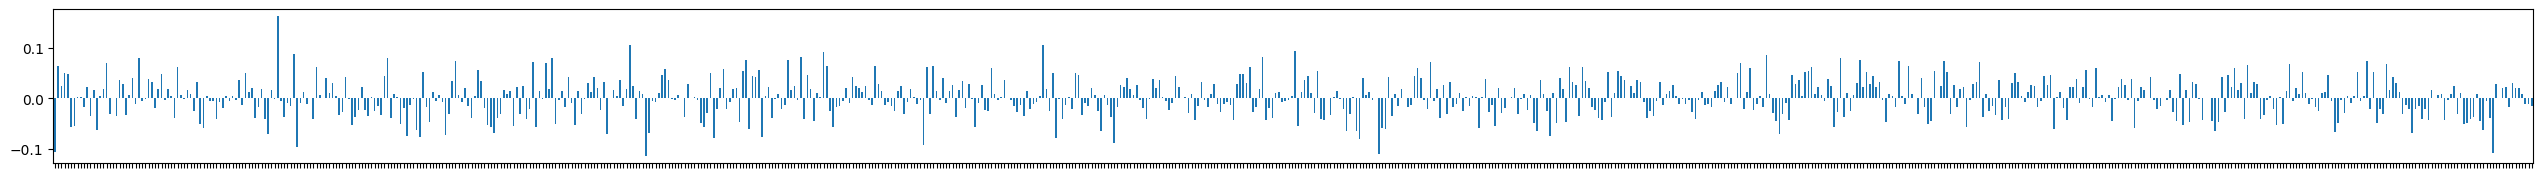


embedding vector for "Iran war Pushes Vulnerable Nations Toward Acute Food Insecurity"


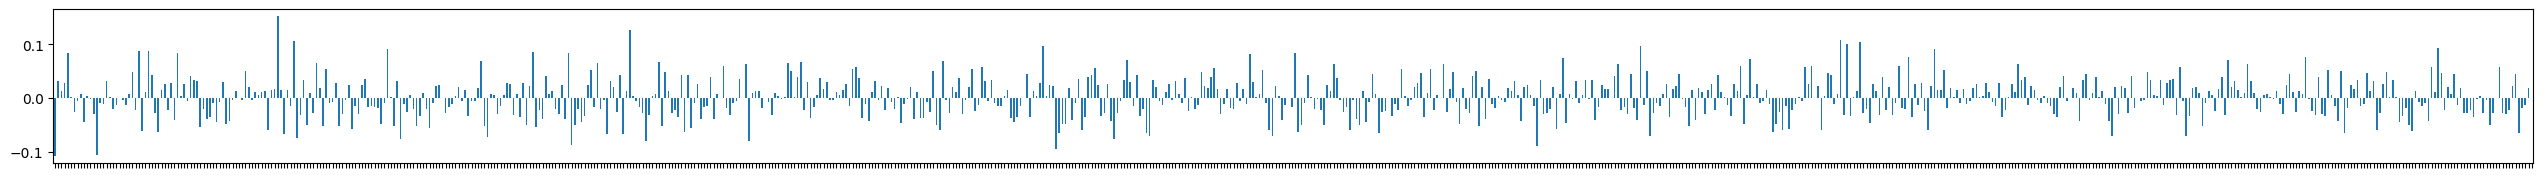


embedding vector for "Nitrogen crisis in the Dutch agricultural sector leads to farmer protests"


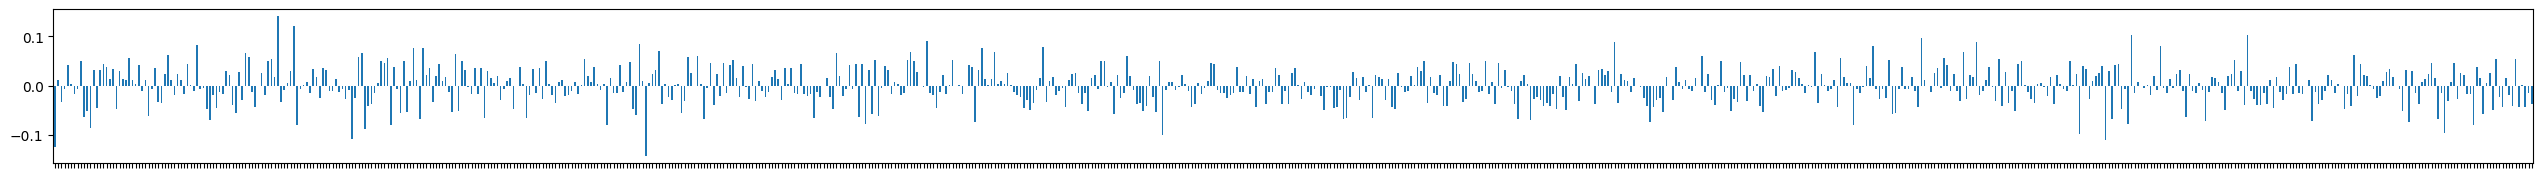

In [19]:
# plot the three embedding vectors
for i, emb in enumerate(embs):
  print(f'embedding vector for "{chunks[i]}"')
  plot_embedding(emb)
  plt.tick_params(axis='x', labelbottom=False)
  plt.show()
  print()

In [20]:
# calculate the cosine similarity between each pair of these three embedding vectors
sim_matrix = cosine_similarity(embs)
sim_matrix

array([[1.0000005 , 0.60636497, 0.3736897 ],
       [0.60636497, 1.        , 0.2937554 ],
       [0.3736897 , 0.2937554 , 1.0000002 ]], dtype=float32)

In [21]:
# visualize the similarities between the embedding vectors of the three documents
pd.DataFrame(sim_matrix, index=chunks, columns=chunks).round(2)

,World Food Programme Warns Middle East Crisis Driving Developing Countries Into Hunger,Iran war Pushes Vulnerable Nations Toward Acute Food Insecurity,Nitrogen crisis in the Dutch agricultural sector leads to farmer protests
World Food Programme Warns Middle East Crisis Driving Developing Countries Into Hunger,1.00,0.61,0.37
Iran war Pushes Vulnerable Nations Toward Acute Food Insecurity,0.61,1.00,0.29
Nitrogen crisis in the Dutch agricultural sector leads to farmer protests,0.37,0.29,1.00


> **✏️ Exercise 1**
>
> Replace the third sentence with your own sentence, and try to guess what the similarities will look like.

# Application: deduplication

Filtering out near-duplicates from a dataset of texts can be done on the basis of cosine similarity and a threshold.

# Application: text retrieval

Text searching often goes beyond searching literal text, and text embeddings are a common way to enhance information retrieval. The cosine similarity between the query and a list of texts can rank these texts in terms of relevance, even when the literal words of the query do not appear in the texts.

In [22]:
# 10 short example sentences (corpus)
corpus = [
    "Rising sea levels threaten coastal cities worldwide.",
    "Heavy rainfall causes severe flooding in urban areas.",
    "Prolonged droughts reduce agricultural yields significantly.",
    "Melting glaciers contribute directly to sea level rise.",
    "Water scarcity is a growing problem in arid regions.",
    "Climate change intensifies extreme weather events.",
    "Groundwater depletion affects local freshwater supplies.",
    "Ocean acidification harms delicate coral reef ecosystems.",
    "Sustainable water management is crucial for the future.",
    "Warmer global temperatures increase evaporation rates.",
]

# A query sentence
query = "How does global warming affect ocean water levels?"

# Encode the corpus and the query
corpus_embeddings = model.encode(corpus)
query_embedding = model.encode([query])

# Calculate cosine similarities
similarities = cosine_similarity(query_embedding, corpus_embeddings)[0]

# Create a Series with the sentences as index, sort by similarity descending
ranking = pd.Series(similarities, index=corpus).sort_values(ascending=False)
ranking

,0
Melting glaciers contribute directly to sea level rise.,0.606681
Rising sea levels threaten coastal cities worldwide.,0.577845
Warmer global temperatures increase evaporation rates.,0.567031
Groundwater depletion affects local freshwater supplies.,0.522346
Ocean acidification harms delicate coral reef ecosystems.,0.480780
Climate change intensifies extreme weather events.,0.476798
Sustainable water management is crucial for the future.,0.445166
Water scarcity is a growing problem in arid regions.,0.426955
Prolonged droughts reduce agricultural yields significantly.,0.400717
Heavy rainfall causes severe flooding in urban areas.,0.385481


> **✏️ Exercise 1**
>
> Add a sentence to the corpus list and rerun the code.
> Try to make your new sentence end up as the most
> similar sentence.

# Application: deduplication

Filtering out near-duplicates from a dataset of texts can be done on the basis of cosine similarity and a threshold.

In [23]:
# short sentences with a semantic near-duplicate
texts = [
    "Rising sea levels threaten coastal cities.",
    "Coastal urban areas are at risk from rising oceans.", # Near-duplicate
    "Heavy rainfall causes severe flooding.",
    "Prolonged droughts reduce agricultural yields.",
    "Melting glaciers contribute to sea level rise.",
    "Water scarcity is a growing problem in arid regions.",
    "Climate change intensifies extreme weather events.",
    "Ocean acidification harms coral reef ecosystems."
]

# Encode the texts
embeddings = model.encode(texts)

# Calculate cosine similarity matrix
sim_matrix = cosine_similarity(embeddings)

# Show similarities
simdf = pd.DataFrame(sim_matrix, index=texts, columns=texts).round(4)
simdf

,Rising sea levels threaten coastal cities.,Coastal urban areas are at risk from rising oceans.,Heavy rainfall causes severe flooding.,Prolonged droughts reduce agricultural yields.,Melting glaciers contribute to sea level rise.,Water scarcity is a growing problem in arid regions.,Climate change intensifies extreme weather events.,Ocean acidification harms coral reef ecosystems.
Rising sea levels threaten coastal cities.,1.0000,0.8375,0.4669,0.4202,0.5797,0.4179,0.4871,0.4539
Coastal urban areas are at risk from rising oceans.,0.8375,1.0000,0.4058,0.3743,0.5058,0.4723,0.4969,0.4757
Heavy rainfall causes severe flooding.,0.4669,0.4058,1.0000,0.4456,0.4069,0.3164,0.5977,0.3977
Prolonged droughts reduce agricultural yields.,0.4202,0.3743,0.4456,1.0000,0.4021,0.4563,0.4182,0.4083
Melting glaciers contribute to sea level rise.,0.5797,0.5058,0.4069,0.4021,1.0000,0.3524,0.4564,0.3927
Water scarcity is a growing problem in arid regions.,0.4179,0.4723,0.3164,0.4563,0.3524,1.0000,0.3491,0.3085
Climate change intensifies extreme weather events.,0.4871,0.4969,0.5977,0.4182,0.4564,0.3491,1.0000,0.4101
Ocean acidification harms coral reef ecosystems.,0.4539,0.4757,0.3977,0.4083,0.3927,0.3085,0.4101,1.0000


In [24]:
simdf_unstacked = simdf.unstack().sort_values(ascending=False)
simdf_unstacked = simdf_unstacked[simdf_unstacked < 1].drop_duplicates()
simdf_unstacked.head(5)

,,0
Coastal urban areas are at risk from rising oceans.,Rising sea levels threaten coastal cities.,0.8375
Heavy rainfall causes severe flooding.,Climate change intensifies extreme weather events.,0.5977
Melting glaciers contribute to sea level rise.,Rising sea levels threaten coastal cities.,0.5797
Coastal urban areas are at risk from rising oceans.,Melting glaciers contribute to sea level rise.,0.5058
Climate change intensifies extreme weather events.,Coastal urban areas are at risk from rising oceans.,0.4969


In [25]:
threshold = 0.8
simdf_unstacked[simdf_unstacked > threshold]

,,0
Coastal urban areas are at risk from rising oceans.,Rising sea levels threaten coastal cities.,0.8375


> **✏️ Exercise 1**
>
> Add two sentences that are near duplicates, and try
> to set the threshold at the right level to filter
> them out.

# Application: keyword extraction

In [26]:
# Define a long example sentence
sentence = '''Rivers naturally meander through valleys, causing erosion and
transporting sediment, gradually reshaping the entire landscape over
thousands of years into intricate networks.'''

# Extract unique words (with basic preprocessing to remove punctuation and make lowercase)
words = list(set(word.strip('.,').lower() for word in sentence.split()))

# Encode the entire sentence and the individual words separately
sentence_embedding = model.encode([sentence])
word_embeddings = model.encode(words)

# Calculate cosine similarity between the full sentence and each word
similarities = cosine_similarity(sentence_embedding, word_embeddings)[0]

# Create a Series to rank the words by similarity
keyword_rankings = pd.Series(similarities, index=words).sort_values(ascending=False)

print("Top extracted keywords:")
print(keyword_rankings.head(5))

Top extracted keywords:
erosion      0.525415
valleys      0.523323
rivers       0.491090
landscape    0.469775
meander      0.455108
dtype: float32


> **✏️ Exercise 1**
> Copy a longer piece of text from a website, and
> extract the top 10 keywords from it

In [27]:
text = '''
Your text here
'''

# add code to extract keywords

# Application: sentiment analysis

In [28]:
drought_sentences = [
    "The drought has completely destroyed this year's harvest.",
    "We are hoping for rain soon to end this terrible drought.",
    "The drought-resistant crops are actually thriving despite the lack of rain.",
    "Water restrictions have been implemented due to the ongoing drought.",
    "It's fascinating to see how the local ecosystem adapts to the drought conditions.",
    "The severe drought is causing widespread panic among the farmers.",
    "Thanks to the new reservoir, we survived the drought without any water shortages.",
    "The long drought has finally come to an end with today's heavy rainfall!",
    "A drought is officially defined as a prolonged period of abnormally low rainfall.",
    "Sadly, the prolonged drought has dried up the village well."
]

In [29]:
text_embeddings = model.encode(drought_sentences)
text_embeddings.shape

(10, 768)

In [30]:
sentiment_categories = ['Positive', 'Negative']

In [31]:
sentiment_categories_emb = model.encode(sentiment_categories)
sentiment_categories_emb.shape

(2, 768)

In [32]:
sentiment_categories_similarities = cosine_similarity(text_embeddings, sentiment_categories_emb)
sentiment_categories_similarities

array([[0.12705454, 0.35692674],
       [0.17926821, 0.24153566],
       [0.26855814, 0.20107286],
       [0.18968695, 0.1956577 ],
       [0.23587061, 0.08738627],
       [0.11209735, 0.21110973],
       [0.32156503, 0.09198701],
       [0.31435883, 0.08723691],
       [0.14074595, 0.16239047],
       [0.1499252 , 0.263002  ]], dtype=float32)

In [33]:
sentdf = pd.DataFrame(sentiment_categories_similarities, index=drought_sentences, columns=sentiment_categories)
sentdf

,Positive,Negative
The drought has completely destroyed this year's harvest.,0.127055,0.356927
We are hoping for rain soon to end this terrible drought.,0.179268,0.241536
The drought-resistant crops are actually thriving despite the lack of rain.,0.268558,0.201073
Water restrictions have been implemented due to the ongoing drought.,0.189687,0.195658
It's fascinating to see how the local ecosystem adapts to the drought conditions.,0.235871,0.087386
The severe drought is causing widespread panic among the farmers.,0.112097,0.211110
"Thanks to the new reservoir, we survived the drought without any water shortages.",0.321565,0.091987
The long drought has finally come to an end with today's heavy rainfall!,0.314359,0.087237
A drought is officially defined as a prolonged period of abnormally low rainfall.,0.140746,0.162390
"Sadly, the prolonged drought has dried up the village well.",0.149925,0.263002


In [34]:
sentdf['sentiment_score'] = sentdf['Positive'] - sentdf['Negative']
sentdf['sentiment_score'].sort_values(ascending=False)

,sentiment_score
"Thanks to the new reservoir, we survived the drought without any water shortages.",0.229578
The long drought has finally come to an end with today's heavy rainfall!,0.227122
It's fascinating to see how the local ecosystem adapts to the drought conditions.,0.148484
The drought-resistant crops are actually thriving despite the lack of rain.,0.067485
Water restrictions have been implemented due to the ongoing drought.,-0.005971
A drought is officially defined as a prolonged period of abnormally low rainfall.,-0.021645
We are hoping for rain soon to end this terrible drought.,-0.062267
The severe drought is causing widespread panic among the farmers.,-0.099012
"Sadly, the prolonged drought has dried up the village well.",-0.113077
The drought has completely destroyed this year's harvest.,-0.229872


> **✏️ Exercise**


> Analyse the sentiment in these sentences, but focus on 'hope' versus 'despair' instead of just 'positive' and 'negative. Store the result in new column called `hope_vs_despair_score`

In [35]:
# Your code here

drought_sentences = [
    "The drought has completely destroyed this year's harvest.",
    "We are hoping for rain soon to end this terrible drought.",
    "The drought-resistant crops are actually thriving despite the lack of rain.",
    "Water restrictions have been implemented due to the ongoing drought.",
    "It's fascinating to see how the local ecosystem adapts to the drought conditions.",
    "The severe drought is causing widespread panic among the farmers.",
    "Thanks to the new reservoir, we survived the drought without any water shortages.",
    "The long drought has finally come to an end with today's heavy rainfall!",
    "A drought is officially defined as a prolonged period of abnormally low rainfall.",
    "Sadly, the prolonged drought has dried up the village well."
]

text_embeddings = model.encode(drought_sentences)
text_embeddings.shape



(10, 768)

# Application: text classification

## Loading and processing the dataset

We use a small dataset of US bill titles, which are labeled according the policy_area the pertain to. We are going to try to predict the policy_area for each title using text embeddings.

In [75]:
# load the dataset from GitHub
url = 'https://raw.githubusercontent.com/denisejroth/bags-vectors-transformers/main/SentenceTransformers/notebooks/bills.csv'
df = pd.read_csv(url)
df

,text,policy_area
0,To limit the fees charged by the National Arch...,Armed Forces and National Security
1,Expressing the sense of the House of Represent...,Armed Forces and National Security
2,"To amend title 10, United States Code, to incl...",Armed Forces and National Security
3,"To amend title 10, United States Code, to prov...",Armed Forces and National Security
4,"To amend title 10, United States Code, to requ...",Armed Forces and National Security
...,...,...
1595,To amend the Internal Revenue Code of 1986 to ...,Taxation
1596,To amend the Internal Revenue Code of 1986 to ...,Taxation
1597,To amend the Internal Revenue Code of 1986 to ...,Taxation
1598,To provide a tax credit for certain expenses a...,Taxation


In [76]:
# store the policy_area labels as categories
categories = sorted(df['policy_area'].unique())
categories

['Armed Forces and National Security',
 'Health',
 'International Affairs',
 'Taxation']

In [77]:
# embed the text column
embeddings = model.encode(df['text'].to_list(), batch_size=32, show_progress_bar=True)
embeddings.shape

Batches:   0%|          | 0/50 [00:00<?, ?it/s]

(1600, 768)

In [78]:
df['emb'] = list(embeddings)
df

,text,policy_area,emb
0,To limit the fees charged by the National Arch...,Armed Forces and National Security,"[-0.11800429, 0.01865289, 0.064892, -0.0108692..."
1,Expressing the sense of the House of Represent...,Armed Forces and National Security,"[-0.11591464, 0.009297373, -0.03781068, 0.0095..."
2,"To amend title 10, United States Code, to incl...",Armed Forces and National Security,"[-0.11900058, -0.035872538, 0.0043717013, 0.03..."
3,"To amend title 10, United States Code, to prov...",Armed Forces and National Security,"[-0.11526862, 0.031046122, -0.01624541, 0.0318..."
4,"To amend title 10, United States Code, to requ...",Armed Forces and National Security,"[-0.12801784, -0.018173914, -0.0019088663, -0...."
...,...,...,...
1595,To amend the Internal Revenue Code of 1986 to ...,Taxation,"[-0.1304778, 0.020991012, -0.0036361315, -0.00..."
1596,To amend the Internal Revenue Code of 1986 to ...,Taxation,"[-0.13537276, 0.012441662, -0.0025625415, 0.01..."
1597,To amend the Internal Revenue Code of 1986 to ...,Taxation,"[-0.13600965, 0.03765638, 0.0051887142, 0.0262..."
1598,To provide a tax credit for certain expenses a...,Taxation,"[-0.119721346, 0.015128343, 0.01462517, -0.001..."


In [93]:
# Train/test split
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["policy_area"])
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
print('train dataset of size', len(train_df), '- test dataset of size' ,len(test_df))

train dataset of size 1280 - test dataset of size 320


## Classifying the texts

Text classification with text embeddings works through comparing the embedding of each text, with an embedding vector that represents the category (the category embedding). The text gets classified into the category with the highest cosine similarity to the text.

In [94]:
# create function to classify a Series of text embeddings, using a list of category embeddings
def classify(embseries, categories, category_embeddings, model):
  '''calculates cosine similarity of each embedding in a Series of text embeddings (embseries)
  with each category in category_embeddings, and returns a 2-column DataFrame with the predicted
  category and the similarity value for each text embeddings, using a Sentence Transformer model'''
  category_similarities = cosine_similarity(np.array(embseries.to_list()), category_embeddings)
  categorydf = pd.DataFrame(category_similarities, columns=categories)
  categorydf['category_pred'] = categorydf[categories].idxmax(axis=1)
  categorydf['category_sim'] = categorydf[categories].max(axis=1)
  return categorydf[['category_pred', 'category_sim']]

### Classification option 1: embed category labels as classification anchors

With this zero-shot type classification we can reasonable classification results (depending on the label formulation and the dataset), but usuall not a very high classification accuracy.

In [95]:
# get embeddings of the labels or categories
print(categories)
categories_emb = model.encode(categories)
categories_emb.shape

['Armed Forces and National Security', 'Health', 'International Affairs', 'Taxation']


(4, 768)

In [96]:
# use classify function to apply classification to the test_df embeddings
test_df[['ZS_category_pred', 'ZS_category_sim']] = classify(test_df['emb'], categories, categories_emb, model)
test_df.ZS_category_pred.value_counts()

,count
ZS_category_pred,
Armed Forces and National Security,130
Taxation,88
International Affairs,53
Health,49


In [97]:
# check accuracy of classification
from sklearn import metrics
print('classification accuracy', metrics.accuracy_score(test_df.policy_area, test_df.ZS_category_pred))

classification accuracy 0.765625


In [98]:
# check all classification metrics (f1-score macro-average is an important one)
from sklearn import metrics
print(metrics.classification_report(test_df.policy_area, test_df.ZS_category_pred))

                                    precision    recall  f1-score   support

Armed Forces and National Security       0.58      0.94      0.71        80
                            Health       0.94      0.57      0.71        80
             International Affairs       0.92      0.61      0.74        80
                          Taxation       0.85      0.94      0.89        80

                          accuracy                           0.77       320
                         macro avg       0.82      0.77      0.76       320
                      weighted avg       0.82      0.77      0.76       320



### Classification option 2: use average category embeddings from train set as classification anchors

Classification accuracy can be significantly enhanced by averaging text embeddings for each category from a training set, and using those as anchors for classifying the texts: each text goes into the category with the most similar average category embedding.

In [99]:
# create category embeddings by averaging text vectors per category in the training dataset
categories_mean_emb = np.array(train_df.groupby('policy_area')['emb'].mean().to_list())
categories_mean_emb.shape

(4, 768)

In [100]:
# use classify function to apply classification to the test_df embeddings
test_df[['mean_category_pred', 'mean_category_sim']] = classify(test_df['emb'], categories, categories_mean_emb, model)
test_df.mean_category_pred.value_counts()

,count
mean_category_pred,
International Affairs,89
Health,83
Taxation,75
Armed Forces and National Security,73


In [101]:
# check accuracy of classification
from sklearn import metrics
print('classification accuracy', metrics.accuracy_score(test_df.policy_area, test_df.mean_category_pred))

classification accuracy 0.9


In [102]:
# check all classification metrics (f1-score macro-average is an important one)
from sklearn import metrics
print(metrics.classification_report(test_df.policy_area, test_df.mean_category_pred))

                                    precision    recall  f1-score   support

Armed Forces and National Security       0.90      0.82      0.86        80
                            Health       0.90      0.94      0.92        80
             International Affairs       0.82      0.91      0.86        80
                          Taxation       0.99      0.93      0.95        80

                          accuracy                           0.90       320
                         macro avg       0.90      0.90      0.90       320
                      weighted avg       0.90      0.90      0.90       320



> **✏️ Exercise**


> A very small training dataset can already be sufficient to significantly enhance classification accuracy. What matters most is the representativeness of the samples in the training dataset - they can even be generated if necessary. Find the code block where the size of the training dataset is defined, change it such that the training dataset is only 10% of the dataset, rerun the classification and check the accuracy. How high are the accuracy scores now for both options? What has changed and why? Here we plot the entire dataset.

## Bonus: visualize embeddings and category centroids

The logic of categorizing each text into the nearest category can be visualized by plotting all the texts, as well as the average category embeddings, as points in a 2-dimensional space. Dimensionality reduction tools like UMAP can be used to reduce the 768-dimensional representation of each text to 2 dimensions, while trying to make sure that text embeddings that are close together (high cosine similarity) in the high-dimensional space are also close together (high cosine similarity) in the 2-dimensional space.

In [89]:
# use UMAP for dimensionality reduction of the 768-dimensional vectors to 2 dimensions (x and y)
from umap import UMAP
umapper2D = UMAP(n_neighbors=15, n_components=2, min_dist=0.0, metric='cosine', unique=True, verbose=True)
umap_embeddings2D = umapper2D.fit_transform(embeddings)
umap_embeddings2D.shape

UMAP(angular_rp_forest=True, metric='cosine', min_dist=0.0, unique=True, verbose=True)
Unique=True -> Number of data points reduced from  1600  to  1564
Most common duplicate is 864  with a count of  3
Fri Sep 18 13:45:45 2026 Construct fuzzy simplicial set
Fri Sep 18 13:45:50 2026 Finding Nearest Neighbors
Fri Sep 18 13:45:50 2026 Finished Nearest Neighbor Search
Fri Sep 18 13:45:50 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Fri Sep 18 13:45:52 2026 Finished embedding


(1600, 2)

In [90]:
# store x and y coordinates in the DataFrame
df[['x', 'y']] = umap_embeddings2D

In [91]:
# add numerical representation of the policy area (for coloring the texts according to category)
policy_area_dict = {cat: i for i, cat in enumerate(categories)}
df['policy_area_nr'] = df.policy_area.map(policy_area_dict)

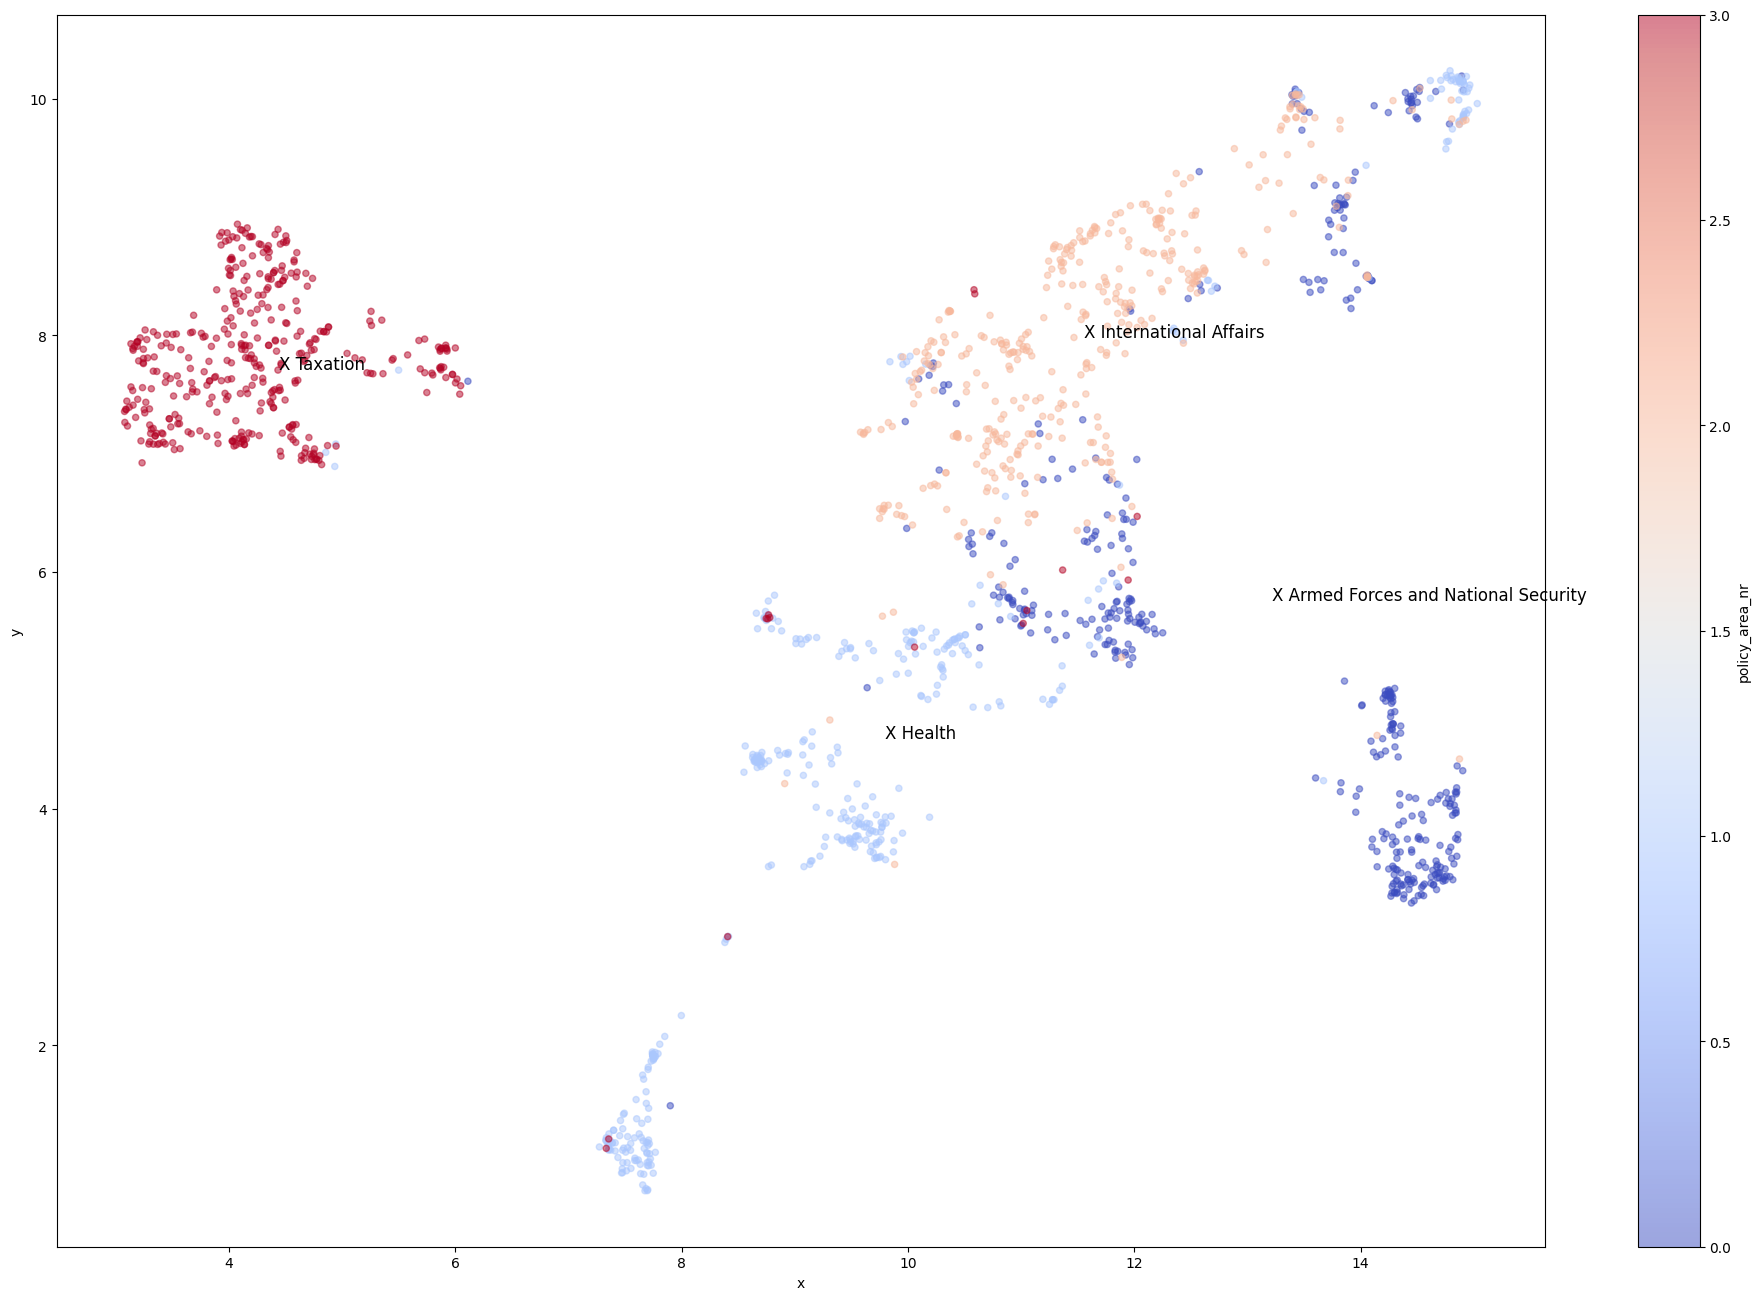

In [92]:
# make a scatter plot of all texts, coloured by policy_area, and with the category centroids marked as X
ax = df.plot.scatter('x', 'y', c='policy_area_nr', cmap='coolwarm', alpha=0.5, figsize=(24,16))
for idx, row in df.groupby('policy_area')[['x', 'y']].mean().iterrows():
  ax.annotate('X ' + idx, (row['x'], row['y']), fontsize=12, color='black')

# Wrap-up

You have now worked with a Sentence Transformer model and explored a number of different applications of this "Swiss army knife" of computational text analysis.

### Where to go next

- Go through the notebook on topic modelling with text embeddings for a more elaborate application
- Browse the **Hugging Face Hub** for Sentence Transformer models: choose Models/sentencetransformer
- Always keep the **Day 1 discipline**: a held-out test set, and an honest baseline to beat.
